# CCO12: Relabel CCO10

In [31]:
import scanpy as sc
import matplotlib.pyplot as plt
import glob
import numpy as np
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import anndata
import os
import scipy
from scipy.cluster.hierarchy import linkage, leaves_list
from matplotlib.colors import ListedColormap
import anndata as ad
import seaborn as sns

In [32]:
WORK_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO12"
PREV_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO10"

In [33]:
os.system(f"mkdir -p {WORK_DIR}")

0

In [68]:
colormap = {
    "CM": (60/255, 170/255, 60/255),
    "EC": (230/255, 80/255, 160/255),
    "MP": (141/255, 160/255, 203/255),
    "PR": (255/255, 235/255, 125/255),
    "CF": (240/255, 180/255, 20/255),
    "SM": (220/255, 160/255, 30/255),
    "OT": (190/255, 190/255, 190/255),
    "OTH": (170/255, 170/255, 170/255),
}

colormap_subclusters = {
    "CM_1": (30/255, 120/255, 30/255),
    "CM_2": (150/255, 230/255, 150/255),
    "CM_3": (15/255, 80/255, 15/255),
    "CM_4": (90/255, 190/255, 90/255),
    "CM_5": (170/255, 240/255, 170/255),
    "CM_6": (190/255, 250/255, 190/255),
    
    "EC_1": (255/255, 200/255, 230/255),
    "EC_2": (230/255, 80/255, 160/255),
    "EC_3": (180/255, 30/255, 120/255),
    
    "PVSC_1": (255/255, 250/255, 200/255),
    "PVSC_2": (255/255, 245/255, 175/255),
    "PVSC_3": (255/255, 240/255, 150/255),
    "PVSC_4": (255/255, 235/255, 125/255),
    "PVSC_5": (255/255, 230/255, 100/255),
    "PVSC_6": (255/255, 220/255, 75/255),
    "PVSC_7": (255/255, 210/255, 50/255),
    "PVSC_8": (255/255, 200/255, 25/255),
    "PVSC_9": (240/255, 180/255, 10/255),
    "PVSC_10": (220/255, 160/255, 0/255),

    "EP": (141/255, 160/255, 203/255),

    "UN": (190/255, 190/255, 190/255),
}

samples = ['ALL', 'VO', 'HO', 'ReAgg-CM', 'Fus-HO', 'VasHO']
samples_old = ['ALL','VO','HO','CA','VHO','VCO']
sample_mapper = {"VO": "VO", "HO": "HO", "CA": "ReAgg-CM", "VHO": "Fus-HO", "VCO": "VasHO"}

cell_types = ['CM', 'PR', 'EC', 'MP', 'CF', 'SM', 'OT']

# 1. Relabel celltype

In [113]:
adata_all = sc.read_h5ad(f"{PREV_DIR}/adata/cell_type_labelled/ALL.h5ad")

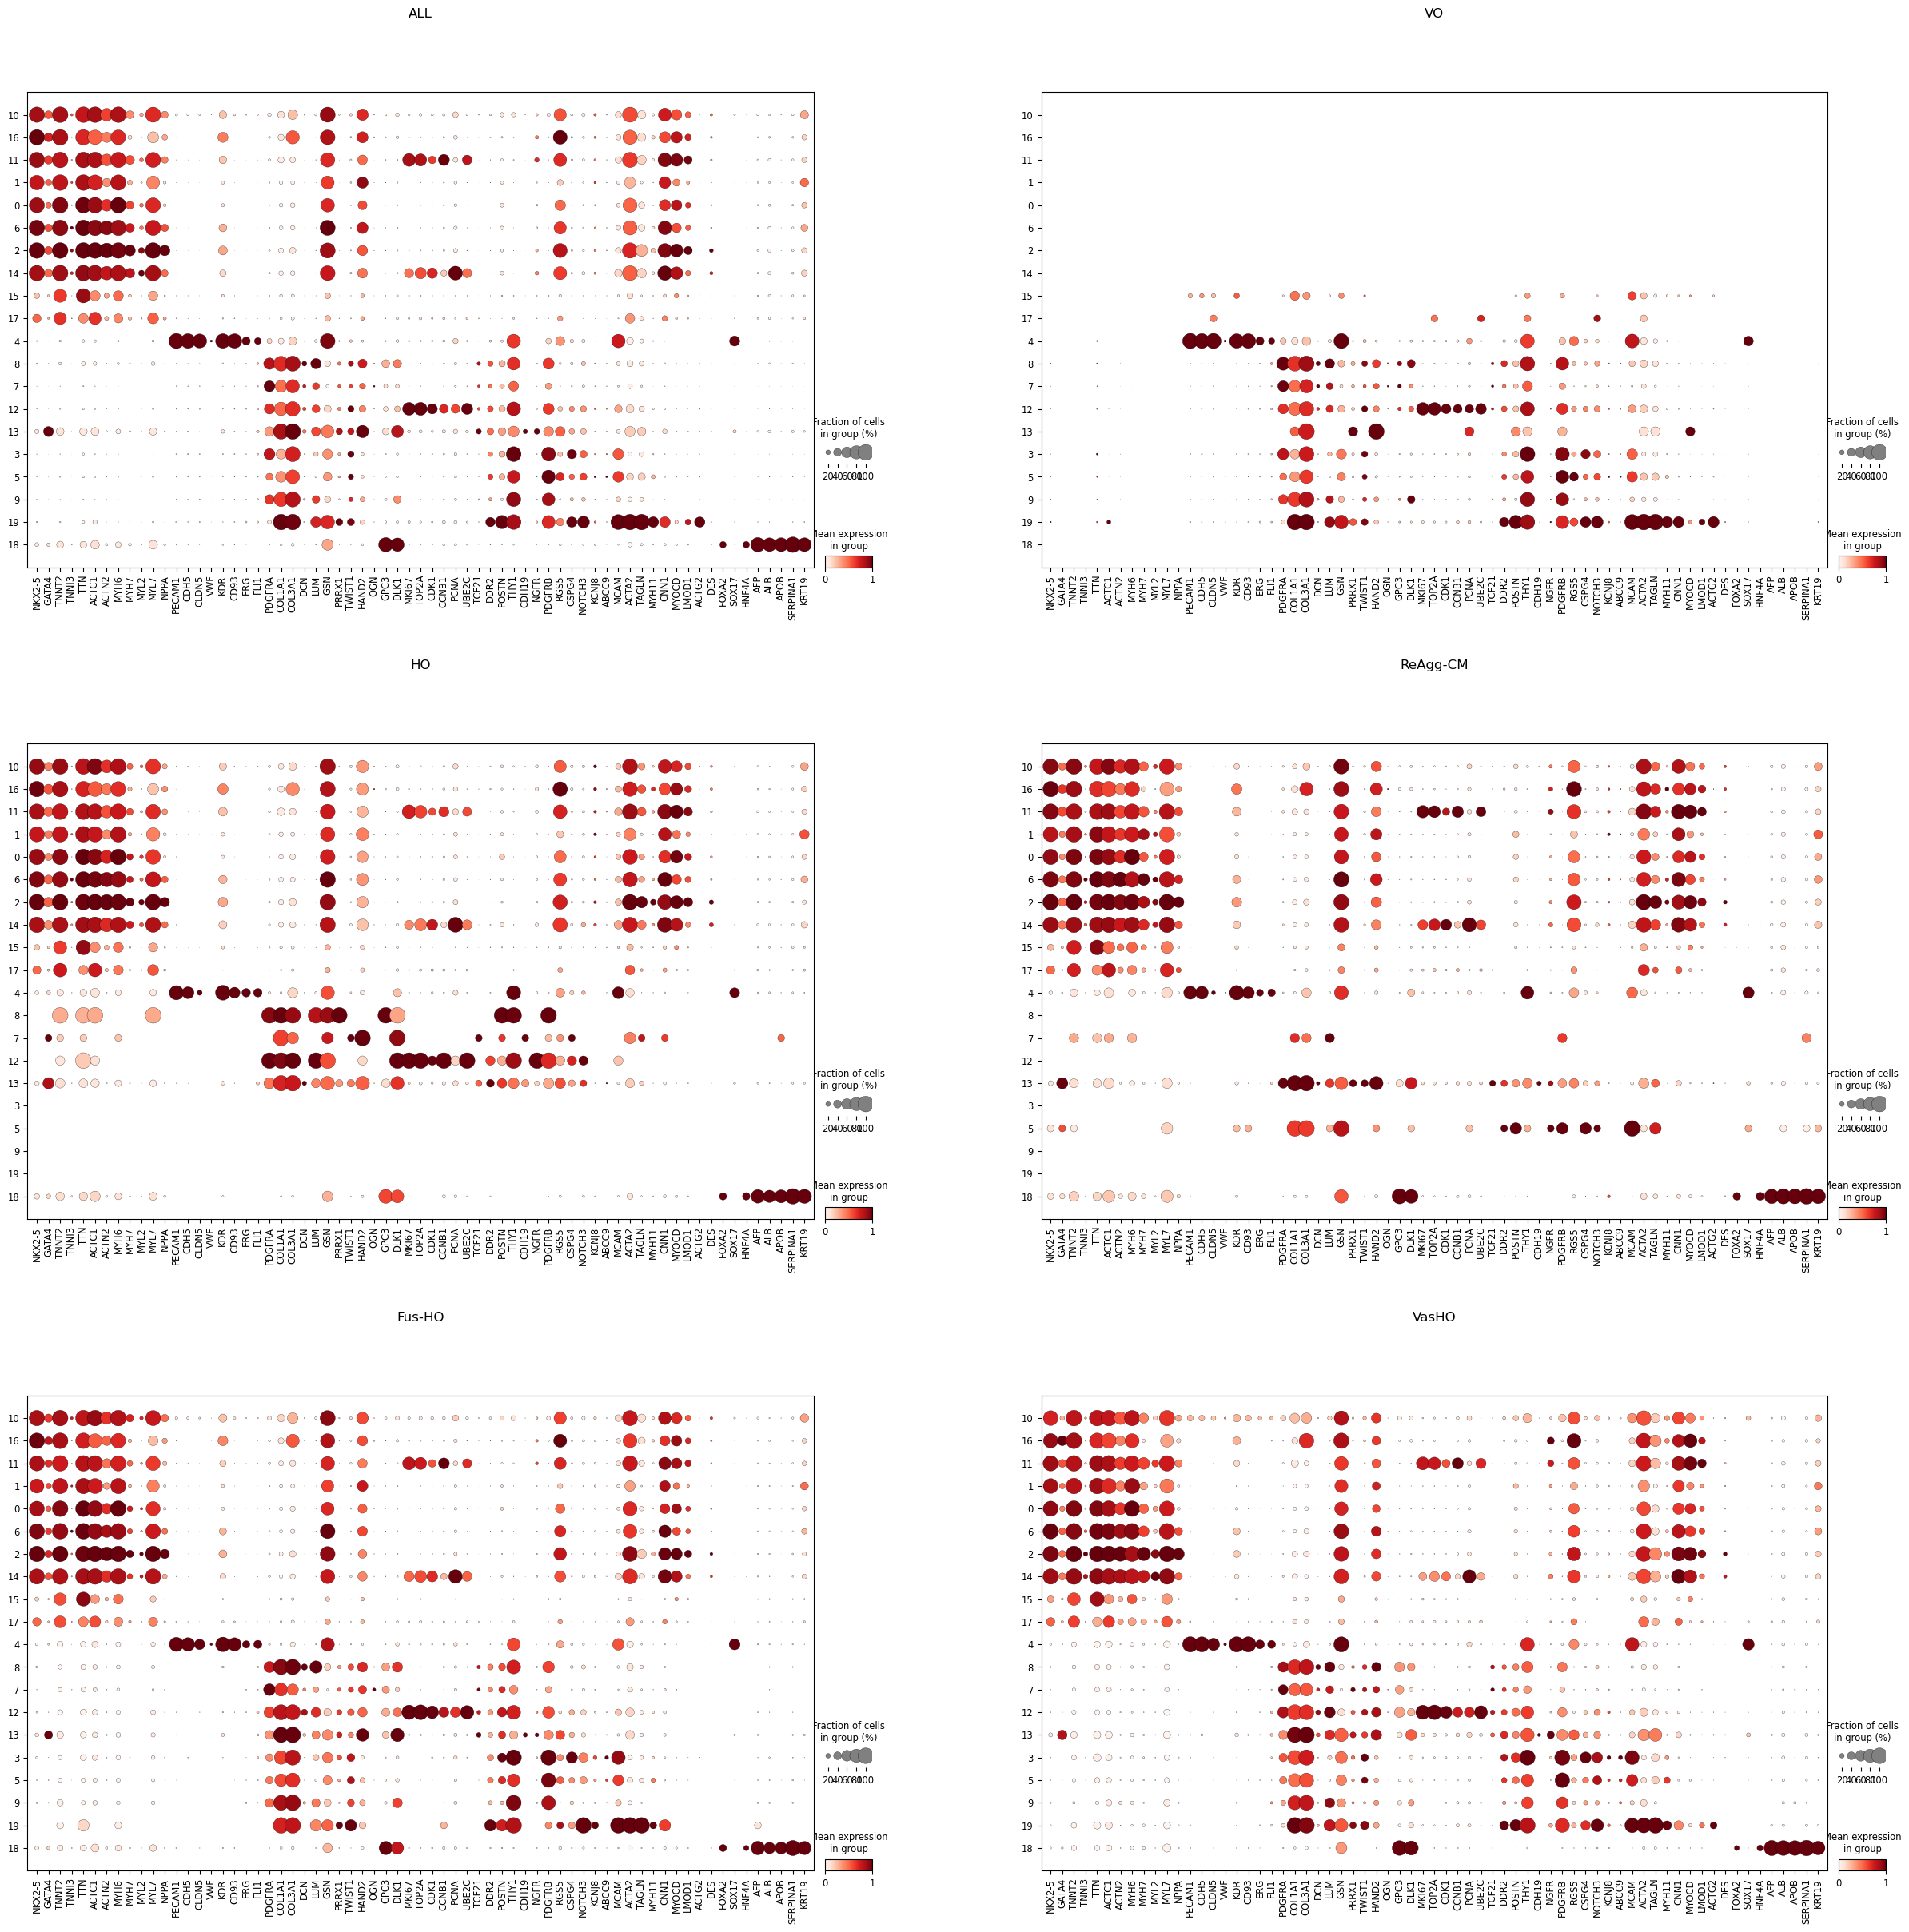

In [114]:
import warnings
warnings.filterwarnings("ignore")

fig, axs = plt.subplots(3, 2, figsize=(30,30), layout="constrained")
axs = axs.flatten()

marker_dict = [
    "NKX2-5", "GATA4", "TNNT2", "TNNI3", "TTN", "ACTC1", "ACTN2", "MYH6", "MYH7", "MYL2", "MYL7", "NPPA",
    "PECAM1", "CDH5", "CLDN5", "VWF", "KDR", "CD93", "ERG", "FLI1",
    "PDGFRA", "COL1A1", "COL3A1", "DCN", "LUM", "GSN", "PRRX1", "TWIST1", "HAND2", "OGN", "GPC3", "DLK1",
    "MKI67", "TOP2A", "CDK1", "CCNB1", "PCNA", "UBE2C",
    "TCF21", "DDR2", "POSTN", "THY1", "CDH19", "NGFR",
    "PDGFRB", "RGS5", "CSPG4", "NOTCH3", "KCNJ8", "ABCC9", "MCAM",
    "ACTA2", "TAGLN", "MYH11", "CNN1", "MYOCD", "LMOD1", "ACTG2", "DES",
    "FOXA2", "SOX17", "HNF4A", "AFP", "ALB", "APOB", "SERPINA1", "KRT19",
]

cluster_order = [10, 16, 11, 1, 0, 6, 2, 14, 15, 17, 4, 8, 7, 12, 13, 3, 5, 9, 19, 18]

for i, sample in enumerate(samples):
    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == samples_old[i]]
    adata.obs['leiden'] = adata.obs['leiden'].astype("int")
    for j in range(0, 20):
        if (adata.obs['leiden'] == j).any():
            continue
        else:
            pat = adata[0].copy()
            pat.obs['leiden'][0] = j
            pat.X.data[:] = 0
            adata = adata.concatenate(pat, batch_key='batch')
    adata.obs['leiden'] = adata.obs['leiden'].astype("category")
    
    sc.pl.dotplot(adata, 
                  marker_dict, 
                  categories_order=cluster_order,
                  groupby="leiden", 
                  standard_scale="var", 
                  ax=axs[i], 
                  title=sample, 
                  show=False)
    
# plt.savefig(f'{WORK_DIR}/dotplot/original_laiden.complete.png')
# plt.savefig(f'{WORK_DIR}/dotplot/original_laiden.complete.svg')
plt.show()

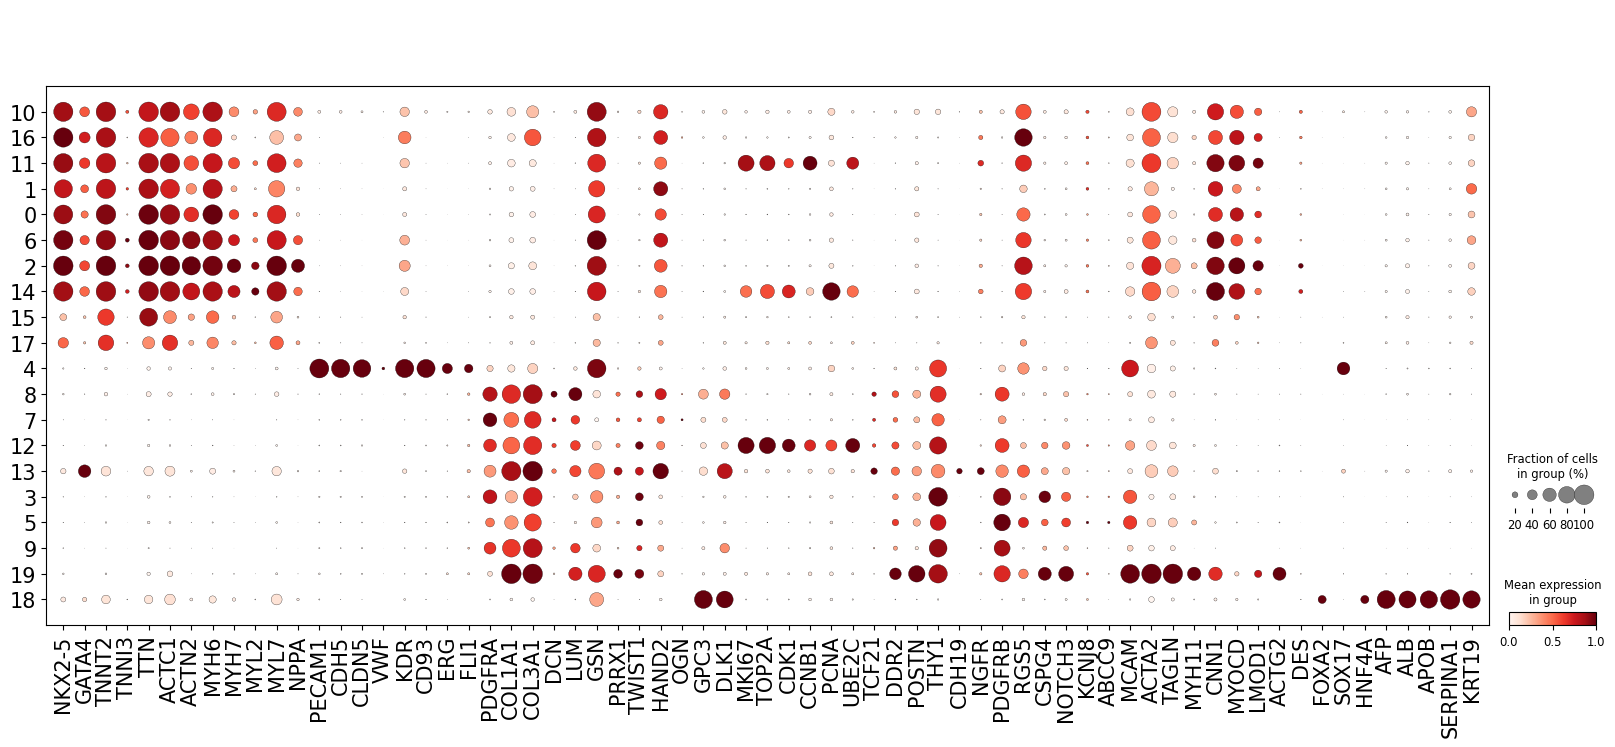

In [115]:
fig, ax = plt.subplots(1, 1, figsize=(20, 8))

dp = sc.pl.dotplot(adata_all,
                   marker_dict, 
                   categories_order=cluster_order,
                   groupby="leiden", 
                   standard_scale="var", 
                   ax=ax, 
                   show=False,
                   return_fig=True)

dp.make_figure()
ax = dp.ax_dict["mainplot_ax"]

ax.tick_params(axis="x", labelsize=15)
ax.tick_params(axis="y", labelsize=15)
plt.show()
plt.close(dp.fig)

In [46]:
celltypes_dict = {
    '0': 'CM',
    '1': 'CM',
    '2': 'CM',
    '3': 'PR',
    '4': 'EC',
    '5': 'PR',
    '6': 'CM',
    '7': 'MP',
    '8': 'MP',
    '9': 'PR',
    '10': 'CM',
    '11': 'CM',
    '12': 'MP',
    '13': 'CF',
    '14': 'CM',
    '15': 'CM',
    '16': 'CM',
    '17': 'CM',
    '18': 'OT',
    '19': 'SM',
}

adata_all.obs['cell_type'] = adata_all.obs['leiden'].map(celltypes_dict)
adata_all.obs['cell_type'] = adata_all.obs['cell_type'].astype("category")

adata_all.obs['batch_old'] = adata_all.obs['batch'].copy()
adata_all.obs['batch'] = adata_all.obs['batch_old'].map(sample_mapper)
adata_all.obs['batch'] = adata_all.obs['batch'].astype("category")

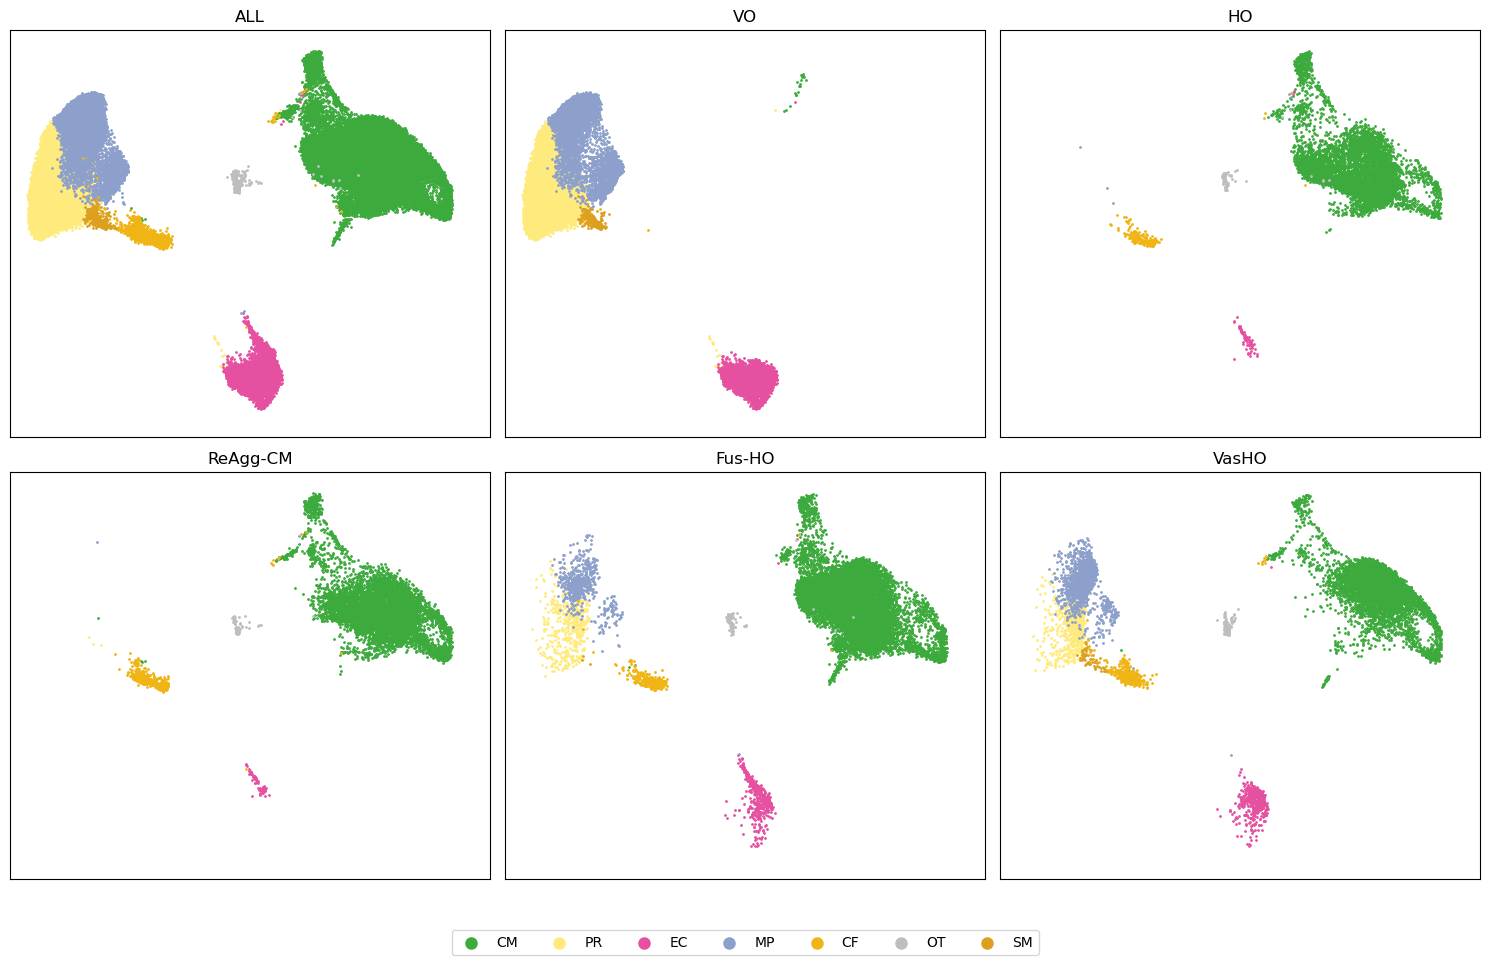

In [36]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for i, sample in enumerate(samples):
    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == samples[i]]
    
    for j, ld in enumerate(adata_all.obs['cell_type'].unique()):
        sbplt = axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type'] == ld, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type'] == ld, 1], 
            label=ld, 
            color=colormap[ld], 
            s=1)
        if i == 0:
            handles.append(sbplt)
            labels.append(ld)
        
    axs[i].set_title(sample)
    axs[i].set_xlim([-11, 21])
    axs[i].set_ylim([-6, 18])
    axs[i].set_xticks([])
    axs[i].set_yticks([])

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=10,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.075)
)

plt.tight_layout()
# plt.savefig(f'{WORK_DIR}/UMAP/original_leiden.complete.png', bbox_inches="tight")
# plt.savefig(f'{WORK_DIR}/UMAP/original_leiden.complete.svg', bbox_inches="tight")
plt.show()

In [37]:
res = {"batch": [], "cell_type": [], "count": []}

for sample, sample_old in zip(samples, samples_old):
    if sample == "ALL":
        continue
    adata = adata_all[adata_all.obs["batch"] == sample]
    # res[sample] = []
    for ct in cell_types:
        res["batch"].append(sample)
        res["cell_type"].append(ct)
        res["count"].append((adata.obs["cell_type"] == ct).sum())

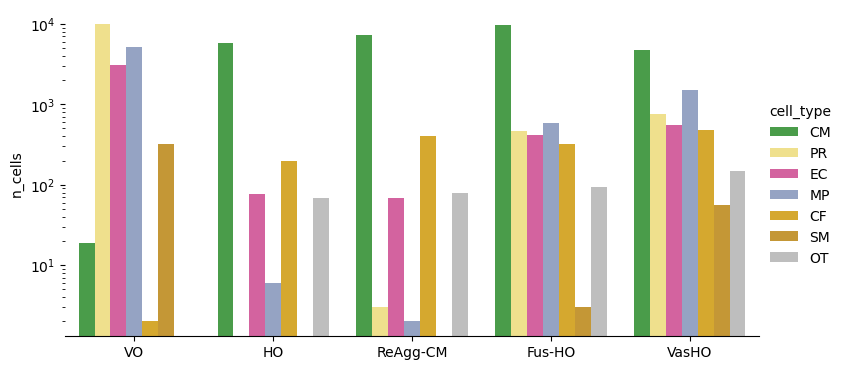

In [38]:
g = sns.catplot(
    data=pd.DataFrame(res), 
    kind="bar",
    x="batch", 
    y="count", 
    hue="cell_type",
    palette=colormap, 
    alpha=1.0, 
    height=4, aspect=2
)
g.despine(left=True)
for ax in g.axes.flat:
    ax.set_yscale("log")
g.set_axis_labels("", "n_cells")

plt.savefig(f"{WORK_DIR}/n_cell.batch.png")
plt.show()

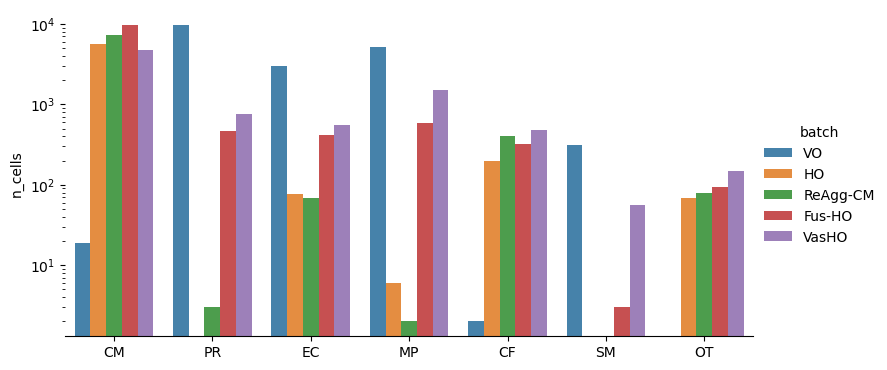

In [39]:
g = sns.catplot(
    data=pd.DataFrame(res), 
    kind="bar",
    x="cell_type", 
    y="count", 
    hue="batch",
    # palette=colormap, 
    alpha=.9, 
    height=4, aspect=2
)
g.despine(left=True)
for ax in g.axes.flat:
    ax.set_yscale("log")
g.set_axis_labels("", "n_cells")

plt.savefig(f"{WORK_DIR}/n_cell.celltype.png")
plt.show()

In [43]:
adata_all.var.drop(columns=['n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2', 'highly_variable-2', 'means-2', 'dispersions-2', 'dispersions_norm-2', 'n_cells_by_counts-3', 'mean_counts-3', 'log1p_mean_counts-3', 'pct_dropout_by_counts-3', 'total_counts-3', 'log1p_total_counts-3', 'highly_variable-3', 'means-3', 'dispersions-3', 'dispersions_norm-3', 'n_cells_by_counts-4', 'mean_counts-4', 'log1p_mean_counts-4', 'pct_dropout_by_counts-4', 'total_counts-4', 'log1p_total_counts-4', 'highly_variable-4', 'means-4', 'dispersions-4', 'dispersions_norm-4'], inplace=True)

In [45]:
os.system(f"mkdir -p {WORK_DIR}/adata/cell_type_labelled")
adata_all.write(f"{WORK_DIR}/adata/cell_type_labelled/ALL.h5ad")
for group in adata_all.obs["batch"].unique():
    adata_all[adata_all.obs["batch"] == group].write(f"{WORK_DIR}/adata/cell_type_labelled/{group}.h5ad")

os.system(f"mkdir -p {WORK_DIR}/adata/cell_type_split")
for ct in adata_all.obs["cell_type"].unique():
    adata_all[adata_all.obs["cell_type"] == ct].write(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")

# 2. Celltype subcluster

In [23]:
os.system(f"mkdir -p {WORK_DIR}/adata/cell_type_subclustered")

0

## 2.1 CM

In [116]:
ct = "CM"
# adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
# sc.tl.leiden(adata, resolution=0.5, random_state=42)
# sc.pl.umap(adata, color="cell_type_subcluster")

# adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
# adata.obs['cell_type_subcluster'] = ct + "_" + (adata.obs['leiden'].astype('int') + 1).astype('str')
# adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')

# adata.write(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

In [117]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

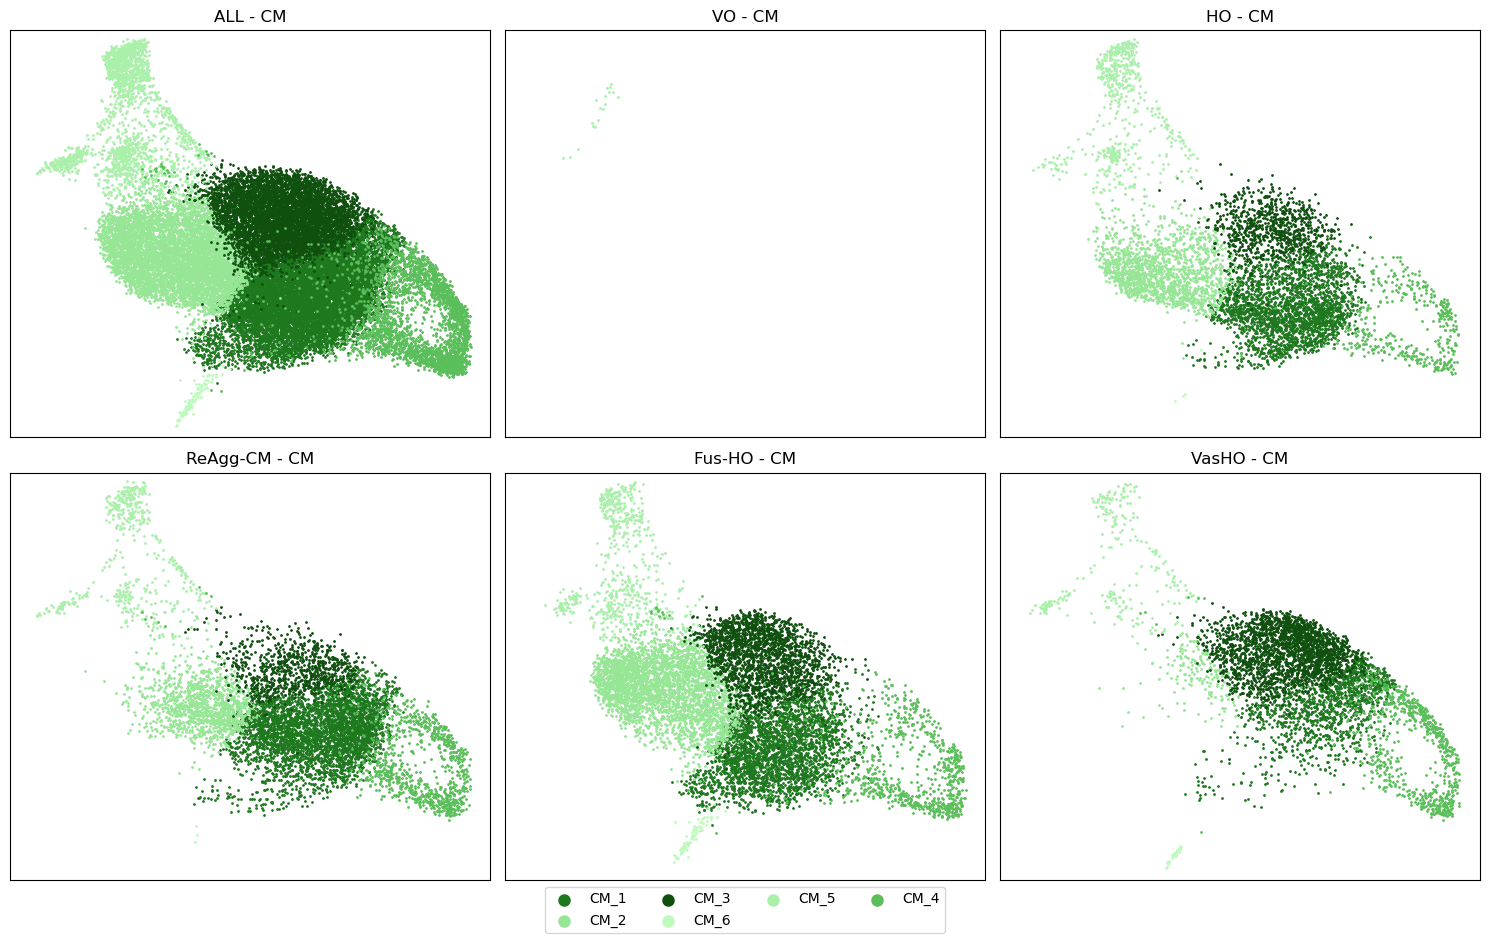

In [118]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for ctsc in adata.obs['cell_type_subcluster'].unique():
        adata_sub = adata_sample[adata_sample.obs['cell_type_subcluster'] == ctsc]
        sbplt = ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=ctsc, s=1, color=colormap_subclusters[ctsc])
        if j == 0:
            handles.append(sbplt)
            labels.append(ctsc)
    
    ax.set_xlim([6, 19])
    ax.set_ylim([5, 17])
    ax.set_title(f"{sample} - {ct}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.legend(
    handles, 
    labels,
    loc='lower center',
    ncol=4,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
# plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{ct}.png', bbox_inches="tight")
# plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{ct}.svg', bbox_inches="tight")
plt.show()

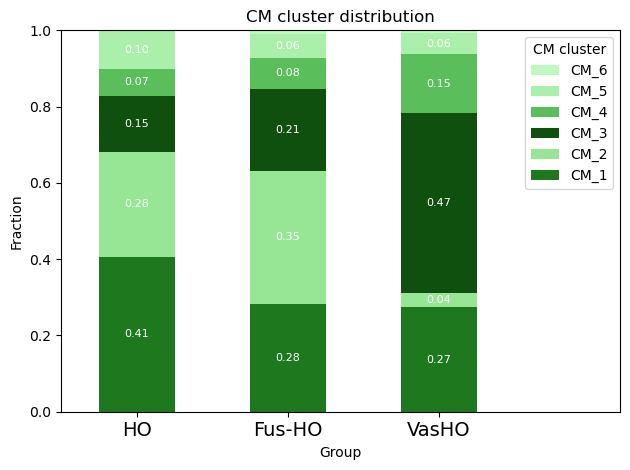

In [119]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'ReAgg-CM' or sample == 'VO':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 3.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
# plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{ct}.png', bbox_inches="tight")
# plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{ct}.svg', bbox_inches="tight")
plt.show()

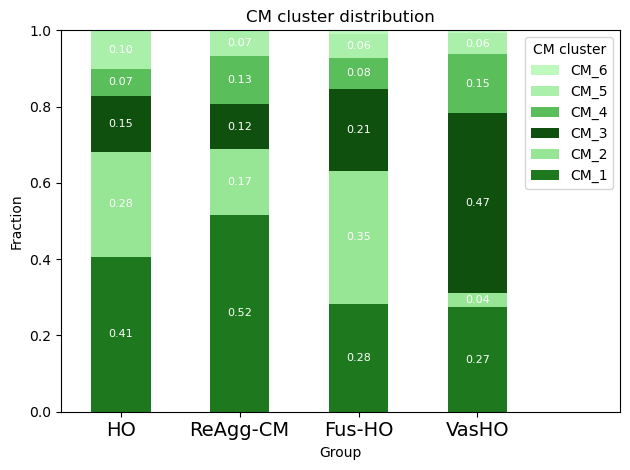

In [120]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'VO':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
# plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{ct}.png', bbox_inches="tight")
# plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{ct}.svg', bbox_inches="tight")
plt.show()

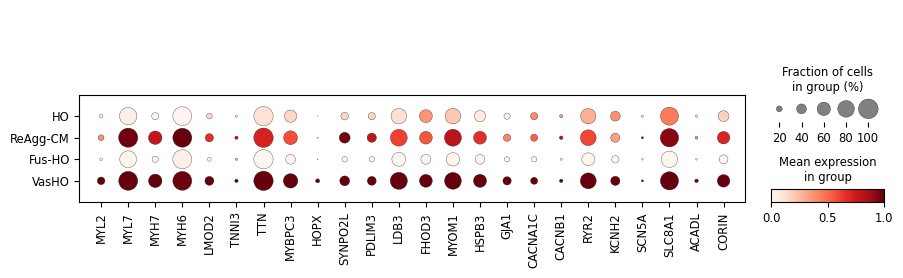

In [123]:
marker_dict = ['MYL2', 'MYL7', 'MYH7', 'MYH6', 'LMOD2', 'TNNI3', 'TTN', 'MYBPC3', 
               'HOPX', 'SYNPO2L', 'PDLIM3', 'LDB3', 'FHOD3', 'MYOM1','HSPB3', 
               'GJA1', 'CACNA1C', 'CACNB1', 'RYR2', 'KCNH2', 'SCN5A', 'SLC8A1', 
               'ACADL', 'CORIN']
categories_order = samples.copy()
categories_order.remove("ALL")
categories_order.remove("VO")

sc.pl.dotplot(adata[adata.obs["batch"] != "VO"], marker_dict, groupby="batch", standard_scale="var", show=False, categories_order=categories_order)
# plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.png', bbox_inches="tight")
# plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.svg', bbox_inches="tight")
plt.show()

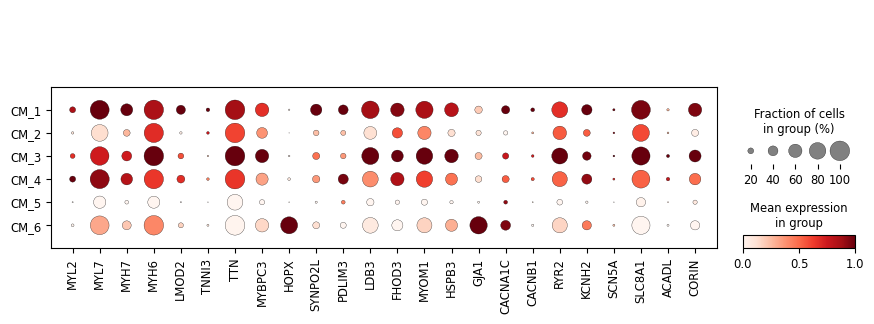

In [127]:
marker_dict = ['MYL2', 'MYL7', 'MYH7', 'MYH6', 'LMOD2', 'TNNI3', 'TTN', 'MYBPC3', 
               'HOPX', 'SYNPO2L', 'PDLIM3', 'LDB3', 'FHOD3', 'MYOM1','HSPB3', 
               'GJA1', 'CACNA1C', 'CACNB1', 'RYR2', 'KCNH2', 'SCN5A', 'SLC8A1', 
               'ACADL', 'CORIN']

sc.pl.dotplot(adata[adata.obs["batch"] != "VO"], marker_dict, groupby="cell_type_subcluster", standard_scale="var", show=False,)
# plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.{ct}.png', bbox_inches="tight")
# plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.{ct}.svg', bbox_inches="tight")
plt.show()

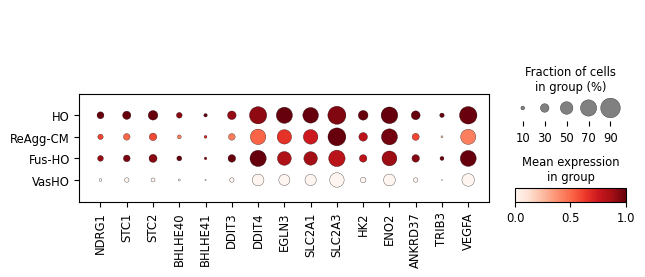

In [124]:
marker_dict = ['NDRG1', 'STC1', 'STC2', 'BHLHE40', 'BHLHE41', 'DDIT3', 'DDIT4', 'EGLN3', 'SLC2A1', 'SLC2A3', 'HK2', 'ENO2', 'ANKRD37', 'TRIB3', 'VEGFA']
categories_order = samples.copy()
categories_order.remove("ALL")
categories_order.remove("VO")

sc.pl.dotplot(adata[adata.obs["batch"] != "VO"], marker_dict, groupby="batch", standard_scale="var", show=False, categories_order=categories_order)
# plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.new.png', bbox_inches="tight")
# plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.new.svg', bbox_inches="tight")
plt.show()

## 2.2 EC

In [81]:
ct = "EC"
# adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
# sc.tl.leiden(adata, resolution=0.3, random_state=42)
# sc.pl.umap(adata, color="leiden")

# adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
# adata.obs['cell_type_subcluster'] = ct + "_" + (adata.obs['leiden'].astype('int') + 1).astype('str')
# adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')

# adata.write(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

In [82]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

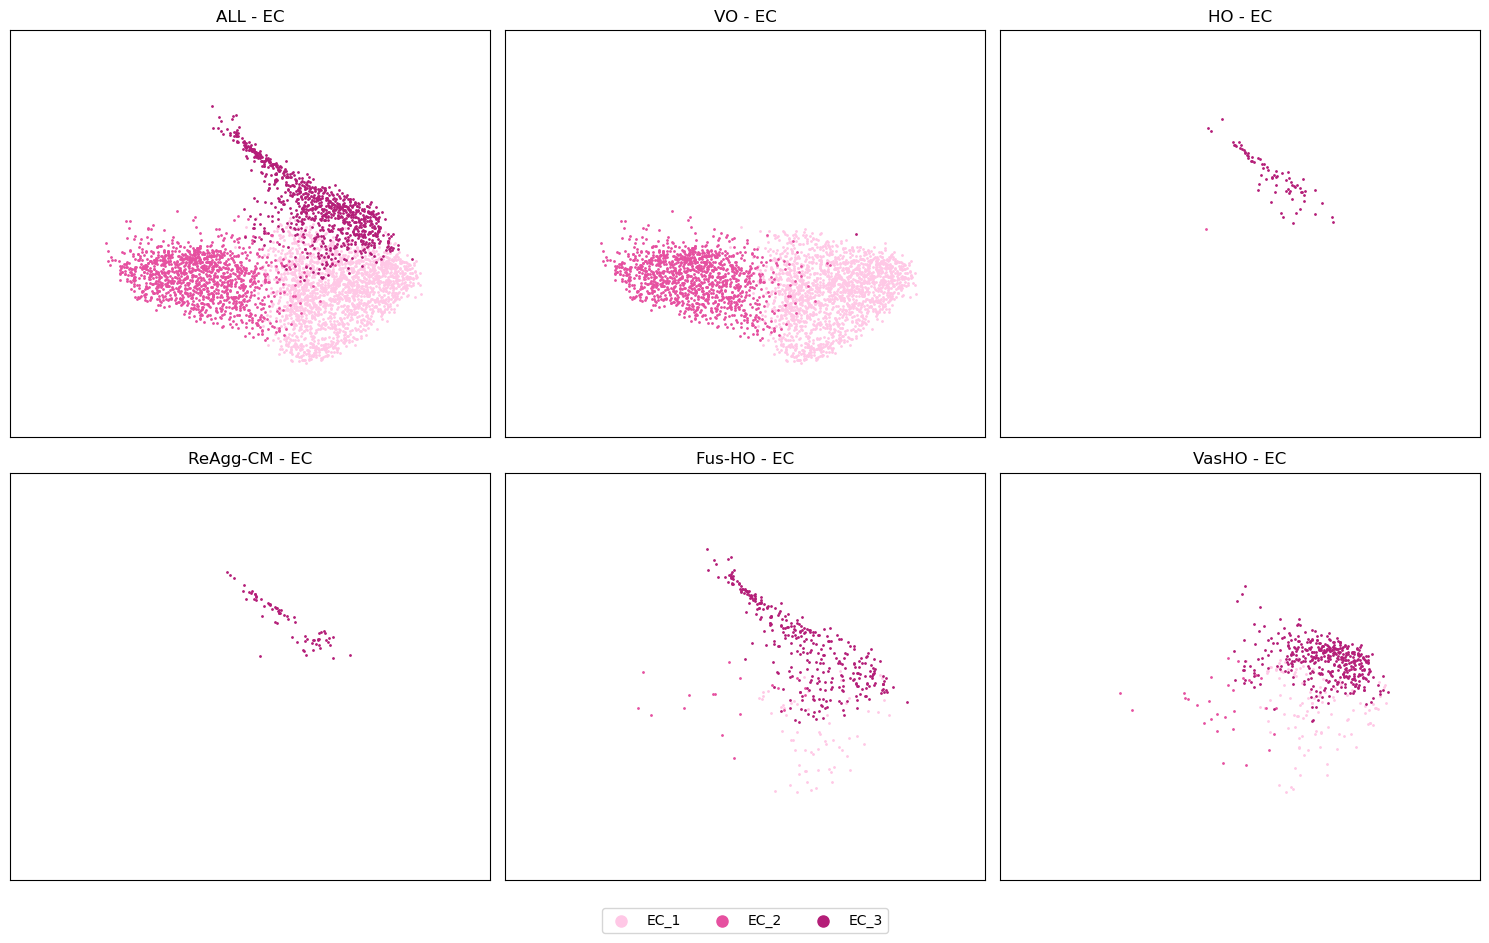

In [84]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for ctsc in adata.obs['cell_type_subcluster'].unique().sort_values():
        adata_sub = adata_sample[adata_sample.obs['cell_type_subcluster'] == ctsc]
        sbplt = ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=ctsc, s=1, color=colormap_subclusters[ctsc])
        if j == 0:
            handles.append(sbplt)
            labels.append(ctsc)
    
    ax.set_xlim([2, 8])
    ax.set_ylim([-6, 3])
    ax.set_title(f"{sample} - {ct}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.legend(
    handles, 
    labels,
    loc='lower center',
    ncol=4,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
# plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{ct}.png', bbox_inches="tight")
# plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{ct}.svg', bbox_inches="tight")
plt.show()

## 2.3 others

# 3. DE

In [59]:
def volcano_plot2(adata1, 
                  label1, 
                  label2, 
                  title, 
                  label_type='cell_type_subcluster', 
                  keygenes=None, 
                  save=None, 
                  save_tsv=None,
                  fc_thres=1, 
                  pvalue_thres=5):
    
    PSEUDOCOUNT=0.0001
    data1 = adata1.X[adata1.obs[label_type] == label1, :].todense().copy() + PSEUDOCOUNT
    data2 = adata1.X[adata1.obs[label_type] == label2, :].todense().copy() + PSEUDOCOUNT

    foldchanges = np.log2(
        np.divide(
            np.mean(data2,axis=0),
            np.mean(data1,axis=0)
        )
    )
    foldchanges = np.squeeze(np.asarray(foldchanges))

    means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
    s = np.squeeze(np.asarray(means)) ** 0.5
    s = s / s.mean() * 5

    ttest_results = scipy.stats.ttest_ind(
        data1,
        data2,
        axis=0,
        equal_var=False
    )
    pvalues = ttest_results[1]
    pvalues[pvalues == 0] = np.min(pvalues[pvalues > 0])
    transformed_pvalues = -1*np.log10(np.array(pvalues))

    idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= pvalue_thres]
    idx_inc = [i for i in idx_signi if foldchanges[i] > fc_thres]
    idx_dec = [i for i in idx_signi if foldchanges[i] < -1 * fc_thres]

    plt.scatter(foldchanges, 
                transformed_pvalues, 
                label='not significant',
                color='grey',
                alpha=0.5,
                s=s)
    plt.scatter(foldchanges[idx_inc], 
                transformed_pvalues[idx_inc], 
                label='up-regulated',
                color='red',
                alpha=0.5,
                s=s[idx_inc])
    plt.scatter(foldchanges[idx_dec], 
                transformed_pvalues[idx_dec], 
                label='down-regulated',
                color='blue',
                alpha=0.5,
                s=s[idx_dec])
    
    if keygenes is not None:
        for keygene in keygenes:
            gene_idx = adata1.var_names.tolist().index(keygene)
            plt.text(foldchanges[gene_idx], transformed_pvalues[gene_idx], keygene, ha='center', va='center')
            

    plt.xlabel('Log2FC')
    plt.ylabel('-log10 p-value')
    plt.title(title)
    plt.legend()
    if save is not None:
        plt.savefig(save)
        plt.close()
    else:
        plt.show()
    
    if save_tsv is not None:
        de_dict = {}
        de_dict['gene'] = adata1.var_names.to_list()
        de_dict['expression_1'] = np.squeeze(np.asarray(np.mean(data1, axis=0))) - PSEUDOCOUNT
        de_dict['expression_2'] = np.squeeze(np.asarray(np.mean(data2, axis=0))) - PSEUDOCOUNT
        de_dict['log2FC'] = foldchanges
        de_dict['-log10 p-val'] = transformed_pvalues
        de_dict['significant'] = [0 if (transformed_pvalues[i] < pvalue_thres or abs(foldchanges[i]) < fc_thres) else 1 for i in range(len(transformed_pvalues))]
        df = pd.DataFrame(de_dict)
        df.to_csv(save_tsv, sep='\t')
        df[df['significant'] == 1].to_csv(f"{(save_tsv).strip('.tsv')}.deg.tsv", sep='\t')

        if keygenes is not None and len(keygenes) > 0:
            df[df['gene'].isin(keygenes)].to_csv(f"{(save_tsv).strip('.tsv')}.marker.tsv", sep='\t')

In [70]:
volcano_plot2(adata_all[adata_all.obs["cell_type"] == "MP"], 
              "VO", 
              "VCO", 
              "MP.VO.VasHO", 
              label_type='batch', 
              keygenes=None, 
              save=f"{WORK_DIR}/MP.VO.VasHO.png", 
              save_tsv=f"{WORK_DIR}/MP.VO.VasHO.tsv",
              fc_thres=1, 
              pvalue_thres=5)

# 4. scVelo

In [78]:
os.system(f"qsub {WORK_DIR}/scVelo/scVelo_job.sh")

requested Hard Resources
  memory (s_vmem): 128G = The job requires 128GB of memory per slot.
  slots (def_slot): 1 = The job requires 100% of CPU.
  total memory: 128G = The job requires 128GB of memory.
Your job 123436903 ("scVelo_job.sh") has been submitted


0